# Epidemiological Intelligence — Modelagem Estatística
## INFARTO AGUDO DO MIOCÁRDIO

## Objetivo

Modelar a relação entre variáveis climáticas e casos de **infarto agudo do miocárdio**, seguindo a metodologia de `02_modeling.ipynb` (implementada em `data_science/src/modeling_utils.py`).

Comparam-se OLS (baseline), Poisson (baseline de contagem) e Binomial Negativa (principal candidata, dado o padrão de sobredispersão observado nas demais doenças). O modelo controla diferenças estruturais entre municípios e sazonalidade mensal (`C(municipality) + C(month)`) e testa se variáveis climáticas — contemporâneas ou defasadas em 1 a 3 meses — agregam capacidade preditiva além desses efeitos fixos.

Validação sempre temporal (treino < 2024-01-01, teste 2024-01 a 2025-12), sem divisão aleatória.

**Nota conceitual**: infarto é um evento multifatorial, fortemente associado a fatores de risco individuais (idade, tabagismo, comorbidades, acesso a saúde) não representados nesta base agregada por município/mês. É um resultado igualmente válido que o clima explique pouco da variação mensal de casos.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import modeling_utils as mu

## 1. Carregamento dos dados

Dados de `epidemiology_climate_monthly` carregados via `mu.load_raw_data()` (cache local em parquet, leitura apenas).

In [2]:
df = mu.load_raw_data()
print(df.shape)

(21384, 19)


In [3]:
df.columns.tolist()

['municipality',
 'year',
 'month',
 'municipality_code',
 'reference_date',
 'cases',
 'source_file',
 'ingestion_timestamp',
 'disease',
 'precipitation_sum_mm',
 'precipitation_avg_observation_mm',
 'precipitation_max_observation_mm',
 'temperature_avg_c',
 'dew_point_avg_c',
 'relative_humidity_avg_pct',
 'atmospheric_pressure_avg_mb',
 'wind_speed_avg_ms',
 'wind_gust_max_ms',
 'station_count']

In [4]:
print(df["reference_date"].dtype)
df["reference_date"].head()

datetime64[ms]


0   2015-01-01
1   2015-01-01
2   2015-01-01
3   2015-01-01
4   2015-01-01
Name: reference_date, dtype: datetime64[ms]

## 2. Lags climáticos

Lags construídos em tabela auxiliar com uma linha por município/mês (`mu.build_climate_monthly_lags`), validando ausência de conflitos, duplicatas e quebras na sequência mensal. O cache já existe em disco; a chamada abaixo só lê o parquet.

In [5]:
climate_monthly = mu.build_climate_monthly_lags(df)
print(climate_monthly.shape)
lag_cols = [c for c in climate_monthly.columns if "_lag" in c]
print("Colunas de lag geradas:", len(lag_cols))
climate_monthly.head()

(3564, 38)
Colunas de lag geradas: 27


,municipality,reference_date,temperature_avg_c,dew_point_avg_c,relative_humidity_avg_pct,atmospheric_pressure_avg_mb,wind_speed_avg_ms,wind_gust_max_ms,precipitation_sum_mm,precipitation_avg_observation_mm,...,wind_gust_max_ms_lag3,precipitation_sum_mm_lag1,precipitation_sum_mm_lag2,precipitation_sum_mm_lag3,precipitation_avg_observation_mm_lag1,precipitation_avg_observation_mm_lag2,precipitation_avg_observation_mm_lag3,precipitation_max_observation_mm_lag1,precipitation_max_observation_mm_lag2,precipitation_max_observation_mm_lag3
0,BAGE,2015-01-01,23.013190,18.240915,76.601615,986.807268,3.125303,21.9,207.4,0.279139,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAGE,2015-02-01,22.666964,18.032440,77.096726,986.839435,3.023065,21.9,87.8,0.130655,...,NaN,207.4,NaN,NaN,0.279139,NaN,NaN,27.0,NaN,NaN
2,BAGE,2015-03-01,21.791667,16.303495,73.721774,988.435484,2.903495,14.0,32.4,0.043548,...,NaN,87.8,207.4,NaN,0.130655,0.279139,NaN,23.0,27.0,NaN
3,BAGE,2015-04-01,18.948889,12.562361,69.625000,990.361389,2.857639,16.3,21.2,0.029444,...,21.9,32.4,87.8,207.4,0.043548,0.130655,0.279139,8.0,23.0,27.0
4,BAGE,2015-05-01,15.845652,11.959103,79.375000,991.782473,2.976223,19.4,126.2,0.171467,...,21.9,21.2,32.4,87.8,0.029444,0.043548,0.130655,9.8,8.0,23.0


In [6]:
check_climate = (
    climate_monthly[
        climate_monthly["municipality"] == "PORTO ALEGRE"
    ][
        [
            "reference_date",
            "temperature_avg_c",
            "temperature_avg_c_lag1",
            "temperature_avg_c_lag2",
            "temperature_avg_c_lag3",
        ]
    ]
    .sort_values("reference_date")
)

display(check_climate.head(12))

,reference_date,temperature_avg_c,temperature_avg_c_lag1,temperature_avg_c_lag2,temperature_avg_c_lag3
1716,2015-01-01,25.451344,NaN,NaN,NaN
1717,2015-02-01,24.657589,25.451344,NaN,NaN
1718,2015-03-01,23.838038,24.657589,25.451344,NaN
1719,2015-04-01,21.052222,23.838038,24.657589,25.451344
1720,2015-05-01,18.313844,21.052222,23.838038,24.657589
1721,2015-06-01,15.567419,18.313844,21.052222,23.838038
1722,2015-07-01,15.573925,15.567419,18.313844,21.052222
1723,2015-08-01,20.317070,15.573925,15.567419,18.313844
1724,2015-09-01,17.169735,20.317070,15.573925,15.567419
1725,2015-10-01,18.522446,17.169735,20.317070,15.573925


In [7]:
df = mu.merge_climate_lags(df, climate_monthly)
print("Shape após merge dos lags:", df.shape)

check_lags = (
    df[
        (df["municipality"] == "PORTO ALEGRE")
        & (df["disease"] == mu.DISEASES["infarto"])
    ][
        [
            "reference_date",
            "cases",
            "temperature_avg_c",
            "temperature_avg_c_lag1",
            "wind_speed_avg_ms",
            "wind_speed_avg_ms_lag1",
            "wind_speed_avg_ms_lag2",
            "wind_speed_avg_ms_lag3",
        ]
    ]
    .sort_values("reference_date")
)

display(check_lags.head(12))

Shape após merge dos lags: (21384, 46)


,reference_date,cases,temperature_avg_c,temperature_avg_c_lag1,wind_speed_avg_ms,wind_speed_avg_ms_lag1,wind_speed_avg_ms_lag2,wind_speed_avg_ms_lag3
81,2015-01-01,177,25.451344,NaN,1.390591,NaN,NaN,NaN
243,2015-02-01,167,24.657589,25.451344,1.473363,1.390591,NaN,NaN
405,2015-03-01,226,23.838038,24.657589,1.498253,1.473363,1.390591,NaN
567,2015-04-01,201,21.052222,23.838038,1.195417,1.498253,1.473363,1.390591
729,2015-05-01,203,18.313844,21.052222,1.181452,1.195417,1.498253,1.473363
891,2015-06-01,188,15.567419,18.313844,0.965867,1.181452,1.195417,1.498253
1053,2015-07-01,239,15.573925,15.567419,1.063575,0.965867,1.181452,1.195417
1215,2015-08-01,219,20.317070,15.573925,1.341667,1.063575,0.965867,1.181452
1377,2015-09-01,245,17.169735,20.317070,1.426220,1.341667,1.063575,0.965867
1539,2015-10-01,231,18.522446,17.169735,1.574462,1.426220,1.341667,1.063575


## 3. Split temporal

Divisão sempre temporal, nunca aleatória: treino com `reference_date < 2024-01-01`, teste de 2024-01 a 2025-12.

In [8]:
train_df, test_df = mu.temporal_split(df)

print("Treino:", train_df["reference_date"].min(), "→", train_df["reference_date"].max())
print("Teste:", test_df["reference_date"].min(), "→", test_df["reference_date"].max())
print("Treino shape:", train_df.shape)
print("Teste shape:", test_df.shape)

Treino: 2015-01-01 00:00:00 → 2023-12-01 00:00:00
Teste: 2024-01-01 00:00:00 → 2025-12-01 00:00:00
Treino shape: (17496, 46)
Teste shape: (3888, 46)


## 4. Filtragem da doença

`DISEASE = "INFARTO AGUDO DO MIOCÁRDIO"`. `mu.prepare_disease_frame` filtra a doença e remove (nunca preenche com zero) linhas sem valores mínimos exigidos (`cases`, `municipality`, `month`).

In [9]:
DISEASE = mu.DISEASES["infarto"]
print(DISEASE)

train_disease0 = mu.prepare_disease_frame(train_df, DISEASE)
test_disease0 = mu.prepare_disease_frame(test_df, DISEASE)

print("train_disease0:", train_disease0.shape)
print("test_disease0:", test_disease0.shape)
print("Municípios:", train_disease0["municipality"].nunique())

INFARTO AGUDO DO MIOCÁRDIO
train_disease0: (2916, 46)
test_disease0: (648, 46)
Municípios: 27


In [10]:
train_disease0["cases"].describe()

count    2916.000000
mean       16.404664
std        47.445101
min         0.000000
25%         0.000000
50%         2.000000
75%         9.000000
max       346.000000
Name: cases, dtype: float64

In [11]:
print("Média:", train_disease0["cases"].mean())
print("Variância:", train_disease0["cases"].var())
print("Razão variância/média:", train_disease0["cases"].var() / train_disease0["cases"].mean())

Média: 16.40466392318244
Variância: 2251.037563146019
Razão variância/média: 137.21936479082262


## 5. Baseline simples, OLS, Poisson e Binomial Negativa simples

Comparação compacta que motiva a escolha da Binomial Negativa: baseline pela média histórica, OLS e Poisson com `temperature_avg_c` como única variável, e checagem de sobredispersão (razão variância/média, confirmada pela dispersão de Pearson do Poisson).

In [12]:
train_t = train_disease0.dropna(subset=["temperature_avg_c"]).copy()
test_t = test_disease0.dropna(subset=["temperature_avg_c"]).copy()

print("Linhas treino (com temperatura):", len(train_t))
print("Linhas teste (com temperatura):", len(test_t))

baseline_pred = train_t["cases"].mean()
test_t["baseline_pred"] = baseline_pred

baseline_mae = mean_absolute_error(test_t["cases"], test_t["baseline_pred"])
baseline_rmse = np.sqrt(mean_squared_error(test_t["cases"], test_t["baseline_pred"]))

print("Média histórica (treino):", baseline_pred)
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Linhas treino (com temperatura): 2844
Linhas teste (com temperatura): 590
Média histórica (treino): 16.69549929676512
Baseline MAE: 27.181260578321297
Baseline RMSE: 62.13864814747249


In [13]:
ols_simple = smf.ols(
    formula="cases ~ temperature_avg_c",
    data=train_t
).fit()

print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  cases   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     5.665
Date:                Wed, 26 Aug 2026   Prob (F-statistic):             0.0174
Time:                        19:20:22   Log-Likelihood:                -15041.
No. Observations:                2844   AIC:                         3.009e+04
Df Residuals:                    2842   BIC:                         3.010e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             6.6271      4.32

In [14]:
test_t["ols_pred"] = ols_simple.predict(test_t)

ols_mae = mean_absolute_error(test_t["cases"], test_t["ols_pred"])
ols_rmse = np.sqrt(mean_squared_error(test_t["cases"], test_t["ols_pred"]))

print("OLS MAE:", ols_mae)
print("OLS RMSE:", ols_rmse)
print("Previsões negativas:", (test_t["ols_pred"] < 0).sum())

OLS MAE: 27.28930639865047
OLS RMSE: 62.12562951167774
Previsões negativas: 0


In [15]:
poisson_simple = smf.glm(
    formula="cases ~ temperature_avg_c",
    data=train_t,
    family=sm.families.Poisson()
).fit()

test_t["poisson_pred"] = poisson_simple.predict(test_t)

poisson_mae = mean_absolute_error(test_t["cases"], test_t["poisson_pred"])
poisson_rmse = np.sqrt(mean_squared_error(test_t["cases"], test_t["poisson_pred"]))

dispersion = poisson_simple.pearson_chi2 / poisson_simple.df_resid

print("Poisson MAE:", poisson_mae)
print("Poisson RMSE:", poisson_rmse)
print("Dispersão (Pearson chi2 / df_resid):", dispersion)

Poisson MAE: 27.300053433766845
Poisson RMSE: 62.126020512966825
Dispersão (Pearson chi2 / df_resid): 136.31696031814067


In [16]:
nb_simple = smf.negativebinomial(
    formula="cases ~ temperature_avg_c",
    data=train_t
).fit(disp=False)

test_t["nb_pred"] = nb_simple.predict(test_t)

nb_mae = mean_absolute_error(test_t["cases"], test_t["nb_pred"])
nb_rmse = np.sqrt(mean_squared_error(test_t["cases"], test_t["nb_pred"]))

print(nb_simple.summary())
print("\nNB (alpha estimado) MAE:", nb_mae)
print("NB (alpha estimado) RMSE:", nb_rmse)

                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 2844
Model:               NegativeBinomial   Df Residuals:                     2842
Method:                           MLE   Df Model:                            1
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:               0.0006285
Time:                        19:20:23   Log-Likelihood:                -8998.9
converged:                       True   LL-Null:                       -9004.5
Covariance Type:            nonrobust   LLR p-value:                 0.0007676
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.1827      0.190     11.513      0.000       1.811       2.554
temperature_avg_c     0.0332      0.010      3.363      0.001       0.014       0.053
alpha                 4.

### Por que migrar para Binomial Negativa com efeitos fixos

Baseline (média histórica): MAE ≈ 27,18, RMSE ≈ 62,14. OLS com temperatura: coeficiente positivo (~0,54, p ≈ 0,017), mas R² ≈ 0,002 e MAE/RMSE praticamente iguais ao baseline — estatisticamente significativo, porém sem capacidade preditiva relevante. Poisson mostrou dispersão de Pearson ≈ 136, confirmando forte sobredispersão (razão variância/média ≈ 137). A Binomial Negativa acomoda essa sobredispersão, mas com apenas temperatura ainda captura pouco, pois a maior parte da heterogeneidade vem de diferenças estruturais entre municípios.

Isso motiva o modelo de referência: Binomial Negativa com efeitos fixos de município e mês, testado a seguir.

## 6. Modelo de referência: Binomial Negativa (município + mês)

Modelo-base da doença, referência para o ganho marginal de qualquer variável climática: `cases ~ C(municipality) + C(month)`, alpha estimado via `smf.negativebinomial` (otimização `bfgs`).

In [17]:
base_model = mu.fit_negbin(mu.BASE_FORMULA, train_disease0)

print("Convergiu:", base_model.mle_retvals.get("converged", False))
print("Alpha:", base_model.params["alpha"])

Convergiu:

 True
Alpha: 0.09438276321270532


In [18]:
base_pred_full = base_model.predict(test_disease0)
base_metrics_full = mu.regression_metrics(test_disease0["cases"], base_pred_full)

print("MAE:", base_metrics_full["mae"])
print("RMSE:", base_metrics_full["rmse"])
print("R²:", base_metrics_full["r2"])
print("WAPE (%):", base_metrics_full["wape_pct"])

MAE:

 6.406261155484642
RMSE: 17.242769160074968
R²: 0.9154428390234883
WAPE (%): 31.479921352499034


O modelo de referência já captura a maior parte da variação estrutural (municípios maiores concentram mais casos) e acomoda a sobredispersão. É a referência para comparar as variáveis climáticas nas próximas seções.

### Correção metodológica: separando a seleção de variáveis do teste final

Numa versão anterior, os testes de variáveis climáticas (seções 7-8) usavam o mesmo período 2024–2025 tanto para escolher a variável "vencedora" quanto para reportar a performance final — um viés de reuso do teste. A partir daqui, a seleção usa `mu.feature_selection_split`: treino-para-seleção em 2015–2022 e validação em 2023, nunca em 2024–2025. O modelo final (seção 10) continua treinado em 2015–2023 e avaliado em 2024–2025, exatamente como antes.

In [19]:
train_fs_df, validation_fs_df = mu.feature_selection_split(train_df)

train_disease_fs = mu.prepare_disease_frame(train_fs_df, DISEASE)
validation_disease_fs = mu.prepare_disease_frame(validation_fs_df, DISEASE)

print("train_disease_fs:", train_disease_fs.shape, train_disease_fs["reference_date"].min(), "->", train_disease_fs["reference_date"].max())
print("validation_disease_fs:", validation_disease_fs.shape, validation_disease_fs["reference_date"].min(), "->", validation_disease_fs["reference_date"].max())

train_disease_fs: (2592, 46) 2015-01-01 00:00:00 -> 2022-12-01 00:00:00
validation_disease_fs: (324, 46) 2023-01-01 00:00:00 -> 2023-12-01 00:00:00


## 7. Contribuição individual das variáveis climáticas

Cada uma das 9 variáveis (`mu.CLIMATE_VARS`) é testada individualmente contra o modelo-base `C(municipality) + C(month)`, com dropna aplicado por variável testada.

In [20]:
mu.CLIMATE_VARS

['temperature_avg_c',
 'dew_point_avg_c',
 'relative_humidity_avg_pct',
 'atmospheric_pressure_avg_mb',
 'wind_speed_avg_ms',
 'wind_gust_max_ms',
 'precipitation_sum_mm',
 'precipitation_avg_observation_mm',
 'precipitation_max_observation_mm']

In [21]:
climate_comparison = mu.evaluate_candidate_features(
    train_disease_fs,
    validation_disease_fs,
    mu.CLIMATE_VARS
)

display(climate_comparison)

,variable,train_n,test_n,coef,pvalue,alpha,base_mae,mae,mae_improvement_pct,base_rmse,rmse,rmse_improvement_pct,base_converged,converged
0,wind_speed_avg_ms,2477,296,0.060893,0.002135,0.079399,6.678574,6.438225,3.598805,17.503476,16.605538,5.130056,True,True
1,precipitation_max_observation_mm,2444,313,0.002232,0.070318,0.081034,6.365970,6.180536,2.912886,17.028874,16.111794,5.385443,True,True
2,relative_humidity_avg_pct,2487,312,0.002831,0.128152,0.081719,6.373350,6.345081,0.443555,17.097088,17.019598,0.453232,True,True
3,precipitation_avg_observation_mm,2444,313,0.032880,0.745049,0.080864,6.365970,6.343455,0.353670,17.028874,16.959293,0.408611,True,True
4,dew_point_avg_c,2486,312,0.002972,0.637684,0.081415,6.373371,6.358621,0.231431,17.096916,17.037388,0.348180,True,True
5,precipitation_sum_mm,2444,313,-0.000002,0.986831,0.080764,6.365970,6.366844,-0.013737,17.028874,17.031549,-0.015703,True,True
6,atmospheric_pressure_avg_mb,2523,314,-0.000705,0.932452,0.081777,6.373706,6.383768,-0.157872,17.027331,17.070288,-0.252284,True,True
7,temperature_avg_c,2530,314,-0.011401,0.170768,0.081276,6.373183,6.403320,-0.472875,17.025512,17.161516,-0.798824,True,True
8,wind_gust_max_ms,2475,296,-0.002694,0.302934,0.080155,6.678866,6.760325,-1.219654,17.499824,17.869655,-2.113340,True,True


Com seleção baseada em 2023, a velocidade média do vento (`wind_speed_avg_ms`) é a melhor variável isolada: melhora de MAE ≈ 3,60% e RMSE ≈ 5,13%, p ≈ 0,0021. A precipitação máxima (`precipitation_max_observation_mm`) vem em segundo (MAE ≈ 2,91%, RMSE ≈ 5,39%), mas sem significância a 5% (p ≈ 0,070). Umidade e ponto de orvalho mostram ganhos pequenos e não significativos; precipitação acumulada, pressão e temperatura contemporâneas não mostram nem significância nem ganho relevante; a rajada máxima de vento piora as métricas.

## 8. Defasagens (lags) das variáveis relevantes

Com base na etapa anterior (avaliada em 2023), seguem para o teste de defasagem as variáveis com melhor resultado e plausibilidade epidemiológica:

- **`wind_speed_avg_ms`** — único ganho isolado significativo (p ≈ 0,0021); ventos mais intensos acompanham frentes frias, associadas a variações de pressão arterial;
- **`precipitation_max_observation_mm`** — segunda melhor (MAE ≈ 2,91%), sem significância a 5%;
- **`atmospheric_pressure_avg_mb`** — associação clássica na literatura a eventos cardiovasculares, mantida por plausibilidade teórica;
- **`temperature_avg_c`** — exposição ao frio (vasoconstrição), mecanismo plausível apesar do resultado fraco anterior.

Para cada uma são testadas a versão contemporânea e defasagens de 1 a 3 meses (`mu.lag_candidates`), treinando em 2015–2022 e avaliando em 2023.

In [22]:
relevant_vars = [
    "wind_speed_avg_ms",
    "precipitation_max_observation_mm",
    "atmospheric_pressure_avg_mb",
    "temperature_avg_c",
]

lag_candidates = mu.lag_candidates(relevant_vars)
print("Número de candidatos testados:", len(lag_candidates))
lag_candidates

Número de candidatos testados: 16


['wind_speed_avg_ms',
 'wind_speed_avg_ms_lag1',
 'wind_speed_avg_ms_lag2',
 'wind_speed_avg_ms_lag3',
 'precipitation_max_observation_mm',
 'precipitation_max_observation_mm_lag1',
 'precipitation_max_observation_mm_lag2',
 'precipitation_max_observation_mm_lag3',
 'atmospheric_pressure_avg_mb',
 'atmospheric_pressure_avg_mb_lag1',
 'atmospheric_pressure_avg_mb_lag2',
 'atmospheric_pressure_avg_mb_lag3',
 'temperature_avg_c',
 'temperature_avg_c_lag1',
 'temperature_avg_c_lag2',
 'temperature_avg_c_lag3']

In [23]:
lag_comparison = mu.evaluate_candidate_features(
    train_disease_fs,
    validation_disease_fs,
    lag_candidates
)

display(lag_comparison)

,variable,train_n,test_n,coef,pvalue,alpha,base_mae,mae,mae_improvement_pct,base_rmse,rmse,rmse_improvement_pct,base_converged,converged
0,wind_speed_avg_ms_lag1,2452,294,0.072531,0.000262,0.077979,6.655571,6.343285,4.692108,17.411428,16.193769,6.993446,True,True
1,wind_speed_avg_ms,2477,296,0.060893,0.002135,0.079399,6.678574,6.438225,3.598805,17.503476,16.605538,5.130056,True,True
2,precipitation_max_observation_mm,2444,313,0.002232,0.070318,0.081034,6.365970,6.180536,2.912886,17.028874,16.111794,5.385443,True,True
3,wind_speed_avg_ms_lag2,2426,295,0.044401,0.028526,0.078347,6.611014,6.439711,2.591166,17.309569,16.714128,3.439954,True,True
4,wind_speed_avg_ms_lag3,2401,295,0.033208,0.098817,0.075814,6.571011,6.453229,1.792447,17.296169,16.878012,2.417627,True,True
5,atmospheric_pressure_avg_mb_lag3,2443,314,0.005906,0.484577,0.078030,6.269222,6.173988,1.519067,16.772758,16.385485,2.308938,True,True
6,atmospheric_pressure_avg_mb_lag1,2497,313,0.006528,0.432606,0.080041,6.321222,6.225867,1.508479,16.890402,16.479755,2.431246,True,True
7,precipitation_max_observation_mm_lag2,2391,313,0.001608,0.198692,0.079104,6.265828,6.177309,1.412720,16.804241,16.483639,1.907866,True,True
8,atmospheric_pressure_avg_mb_lag2,2470,314,0.005336,0.531869,0.079251,6.278411,6.190184,1.405244,16.796119,16.413493,2.278061,True,True
9,precipitation_max_observation_mm_lag1,2418,312,0.000595,0.633018,0.079534,6.329208,6.292063,0.586874,16.905290,16.765167,0.828870,True,True


A defasagem de 1 mês do vento (`wind_speed_avg_ms_lag1`) é o melhor resultado entre todos os candidatos: melhora de MAE ≈ 4,69% e RMSE ≈ 6,99% (p ≈ 0,00026). A versão contemporânea (MAE ≈ 3,60%) e a precipitação contemporânea (MAE ≈ 2,91%, não significativa) vêm em seguida. As defasagens de 2 e 3 meses do vento também melhoram na mesma direção (MAE ≈ 2,59% e 1,79%; p ≈ 0,029 e 0,099), reforçando que o efeito não é isolado a uma única defasagem.

Pressão atmosférica (1-3 meses) e precipitação (defasagem 2) mostram ganhos pequenos (MAE 1,4-1,5%) sem significância (p 0,20-0,53). Defasagens de temperatura chegam a p-valores baixos (ex.: lag2, p ≈ 0,011) mas com coeficiente negativo e piora de MAE/RMSE — outro exemplo de que significância estatística não implica capacidade preditiva.

### Verificação: vale a pena combinar com a segunda variável mais promissora?

Antes de fixar a feature única, testa-se a combinação de `wind_speed_avg_ms_lag1` com `precipitation_max_observation_mm_lag2` via `mu.fit_final_models`, para ver se o ganho adicional justifica incluir uma segunda variável sem significância isolada. Avaliado sempre sobre o split de seleção (2015–2022 / 2023), nunca sobre 2024–2025.

In [24]:
combo_features = ["wind_speed_avg_ms_lag1", "precipitation_max_observation_mm_lag2"]
resultado_combo = mu.fit_final_models(train_disease_fs, validation_disease_fs, combo_features)

print("Melhora MAE (%):", resultado_combo["mae_improvement_pct"])
print("Melhora RMSE (%):", resultado_combo["rmse_improvement_pct"])
print("Convergiu:", resultado_combo["final_converged"])
print("P-valores:")
print(resultado_combo["final_model"].pvalues[combo_features])

correlation = (
    train_disease_fs.dropna(subset=combo_features)[combo_features]
    .corr()
    .iloc[0, 1]
)
print("Correlacao entre as duas variaveis (treino-para-selecao):", correlation)

Melhora MAE (%): 5.504028737419278
Melhora RMSE (%): 8.038352899500275
Convergiu: True
P-valores:
wind_speed_avg_ms_lag1                   0.001791
precipitation_max_observation_mm_lag2    0.210779
dtype: float64
Correlacao entre as duas variaveis (treino-para-selecao): -0.09345999101538319


## 9. Seleção das features finais

Considerando desempenho fora da amostra de seleção (2023), significância estatística, coerência epidemiológica, convergência e multicolinearidade, a feature final é:

- **`wind_speed_avg_ms_lag1`**

É a única variável, entre as 9 contemporâneas e 16 combinações de defasagem, com melhora consistente de MAE e RMSE, p-valor abaixo de 1% e efeito que se repete na mesma direção nas defasagens de 2 e 3 meses (reduzindo a chance de resultado espúrio). A combinação com `precipitation_max_observation_mm_lag2` aumenta o ganho na validação (MAE ≈ 5,50%, RMSE ≈ 8,04%), mas essa segunda variável não é significativa no modelo combinado (p ≈ 0,21), apesar da baixa colinearidade entre elas (ρ ≈ -0,09). Optou-se por um modelo parcimonioso com uma única variável climática; o fato de a mesma variável ter sido selecionada tanto sob a metodologia original (com viés de reuso do teste) quanto sob a validação independente em 2023 é um indício adicional — não uma prova — de que o achado não é um artefato do processo de seleção.

In [25]:
final_features = ["wind_speed_avg_ms_lag1"]
final_features

['wind_speed_avg_ms_lag1']

## 10. Modelo multivariado final

Ajuste do modelo-base e do modelo final multivariado nas mesmas linhas (via `mu.fit_final_models`), garantindo comparação justa.

In [26]:
resultado = mu.fit_final_models(
    train_disease0,
    test_disease0,
    final_features
)

print("Convergiu (base):", resultado["base_converged"])
print("Convergiu (final):", resultado["final_converged"])
print("Alpha (final):", resultado["alpha"])
print("Fórmula final:", resultado["formula"])
print("Linhas treino:", len(resultado["train_final"]))
print("Linhas teste:", len(resultado["test_final"]))

Convergiu (base): True
Convergiu (final): True
Alpha (final): 0.0901847136388291
Fórmula final: cases ~ C(municipality) + C(month) + wind_speed_avg_ms_lag1
Linhas treino: 2746
Linhas teste: 578


In [27]:
final_model = resultado["final_model"]
print(final_model.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 2746
Model:               NegativeBinomial   Df Residuals:                     2707
Method:                           MLE   Df Model:                           38
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:                  0.3569
Time:                        19:20:27   Log-Likelihood:                -5613.0
converged:                       True   LL-Null:                       -8727.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   2.0087      0.092     21.856      0.000       1.829       2.189
C(municipality)[T.BENTO GONCALVES]         -

In [28]:
print("AIC:", final_model.aic)
print("Log-Likelihood:", final_model.llf)

AIC: 11305.9108858851
Log-Likelihood: -5612.95544294255


In [29]:
base_metrics = resultado["base_metrics"]
final_metrics = resultado["final_metrics"]

print("BASE (mesmas linhas do modelo final)")
print("MAE:", base_metrics["mae"])
print("RMSE:", base_metrics["rmse"])
print("R²:", base_metrics["r2"])
print("WAPE (%):", base_metrics["wape_pct"])

print("\nMODELO FINAL (com clima)")
print("MAE:", final_metrics["mae"])
print("RMSE:", final_metrics["rmse"])
print("R²:", final_metrics["r2"])
print("WAPE (%):", final_metrics["wape_pct"])

print("\nMelhora MAE (%):", resultado["mae_improvement_pct"])
print("Melhora RMSE (%):", resultado["rmse_improvement_pct"])

BASE (mesmas linhas do modelo final)
MAE: 6.731573414233557
RMSE: 18.099197328781578
R²: 0.916195920431559
WAPE (%): 30.421027626481596

MODELO FINAL (com clima)
MAE: 6.643112034913399
RMSE: 17.768983992625436
R²: 0.9192259753219663
WAPE (%): 30.021256889600817

Melhora MAE (%): 1.314126339811004
Melhora RMSE (%): 1.8244639812343069


O modelo final converge e o coeficiente de `wind_speed_avg_ms_lag1` é positivo e estatisticamente significativo (p < 0,001) mesmo controlando por município e mês. Frente ao modelo-base (mesmas linhas), há melhora de ≈ 1,3% no MAE e ≈ 1,8% no RMSE em 2024–2025 — ganho real, porém modesto, coerente com o clima explicando apenas uma parte pequena da ocorrência de infarto quando município e sazonalidade já estão controlados. Esses números não mudaram com a correção metodológica das seções anteriores, pois a variável selecionada foi a mesma.

## 11. Backtest e gráficos

### A) Real vs previsto (global, 2024–2025)

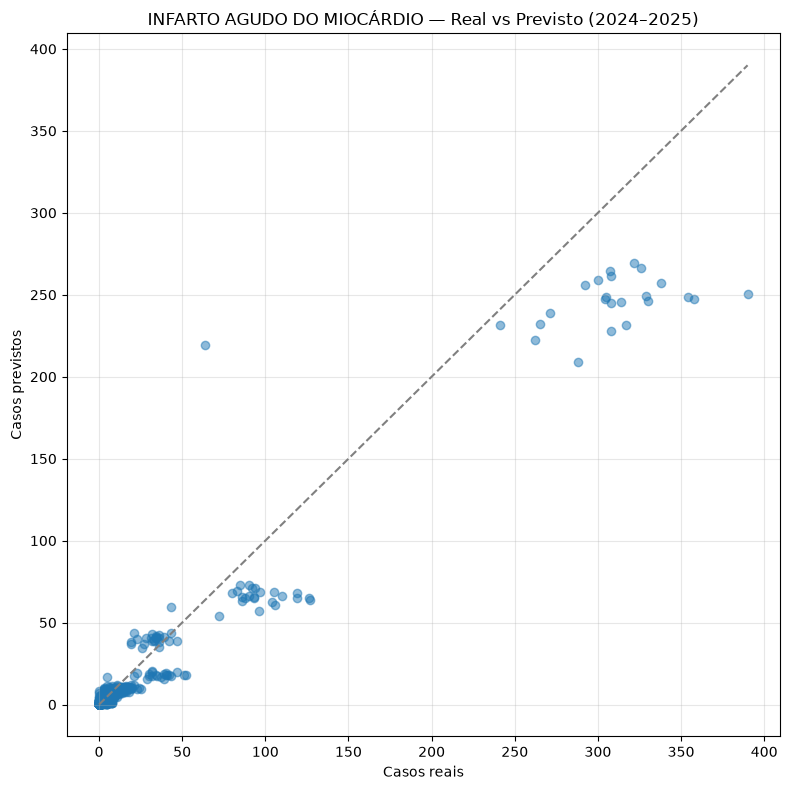

In [30]:
mu.plot_real_vs_predicted(
    resultado["test_final"]["cases"],
    resultado["final_pred"],
    DISEASE
)

### B) Backtest temporal por município

Porto Alegre concentra o maior volume de casos e é o foco do backtest; Passo Fundo e Rio Grande são o 2º e o 3º municípios com mais casos no treino.

In [31]:
historical_df = resultado["train_final"]
forecast_df = resultado["test_final"].copy()
forecast_df["prediction"] = resultado["final_pred"]

plot_backtest = mu.make_backtest_plotter(DISEASE, historical_df, forecast_df)

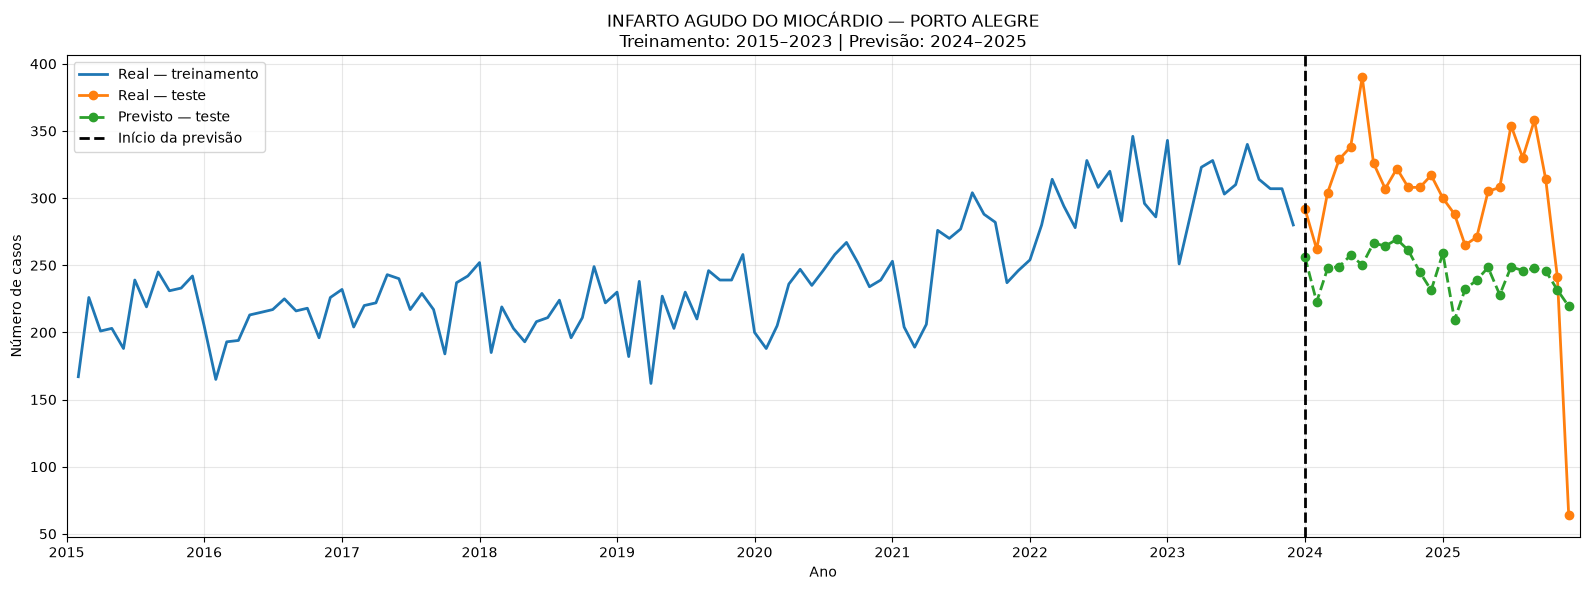

In [32]:
plot_backtest("PORTO ALEGRE")

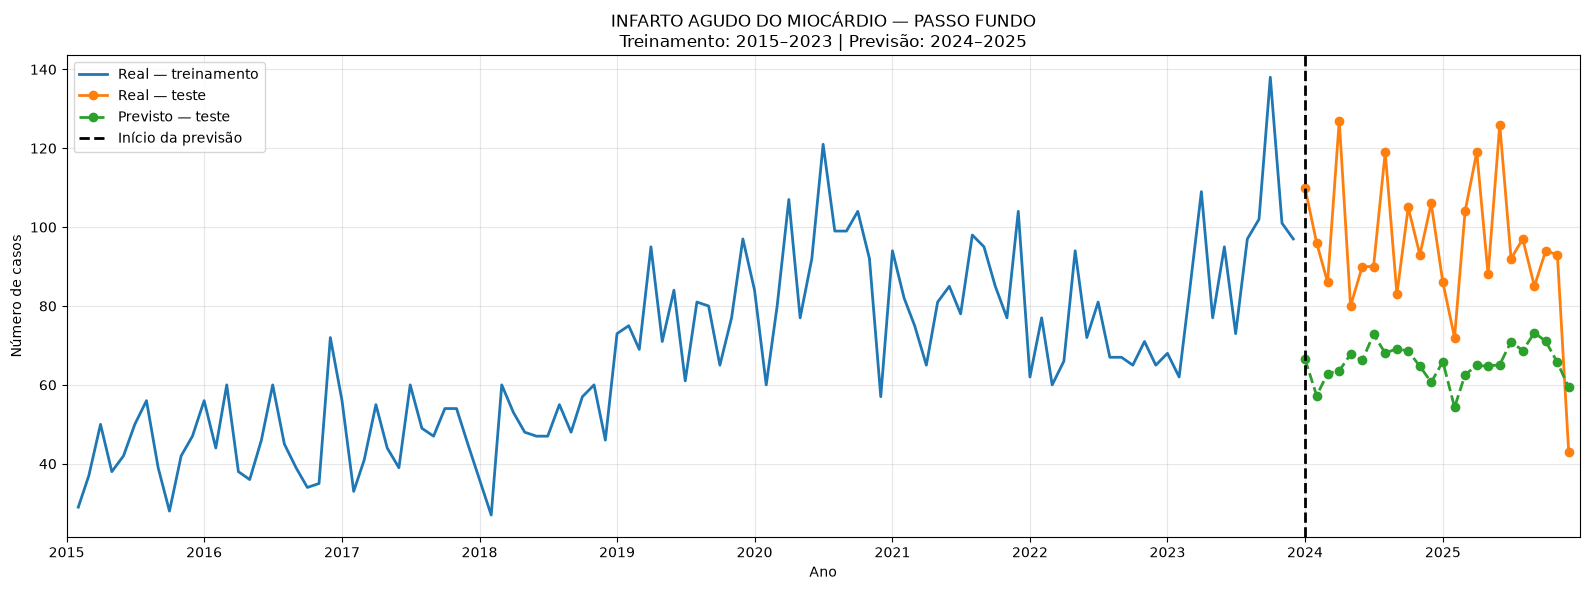

In [33]:
plot_backtest("PASSO FUNDO")

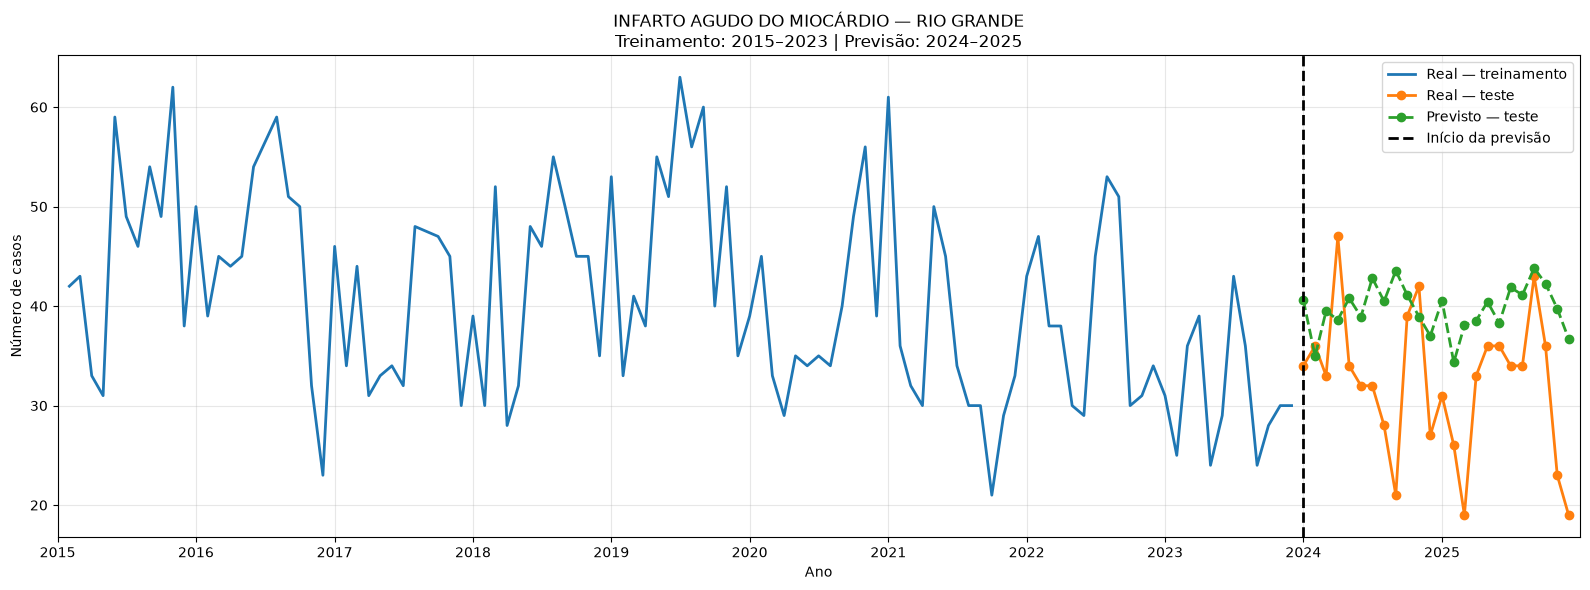

In [34]:
plot_backtest("RIO GRANDE")

### C) Baseline vs modelo climático vs real (2024–2025) — Porto Alegre

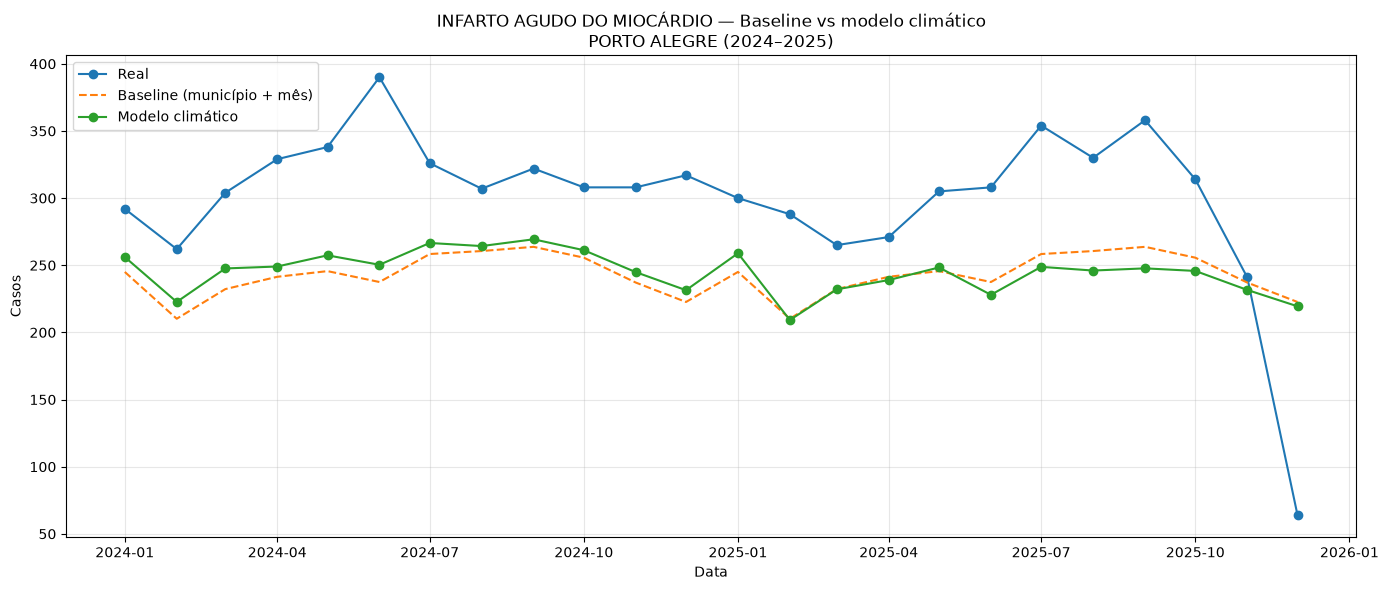

In [35]:
plot_df = resultado["test_final"][
    resultado["test_final"]["municipality"] == "PORTO ALEGRE"
].copy()

plot_df["baseline_pred"] = resultado["base_model"].predict(plot_df)
plot_df["climate_pred"] = resultado["final_model"].predict(plot_df)

mu.plot_baseline_vs_climate(DISEASE, "PORTO ALEGRE", plot_df)

### D) Tabela de métricas por município

**Atenção**: WAPE e MAE normalizado não devem ser interpretados como "acurácia", especialmente em municípios com poucos casos ou meses com zero casos — pequenos erros absolutos podem gerar percentuais de erro muito altos nesses casos.

In [36]:
evaluation_df = resultado["test_final"][
    ["municipality", "reference_date", "cases"]
].copy()
evaluation_df["prediction"] = resultado["final_pred"]

municipality_table = mu.municipality_metrics_table(evaluation_df)
display(municipality_table)

,municipality,n,mean_cases,mae,rmse,wape_pct,r2
0,TEUTONIA,19,0.052632,0.136161,0.228366,258.706569,-0.045919
1,LAGOA VERMELHA,24,0.041667,0.233352,0.261260,560.045980,-0.709384
2,SANTO AUGUSTO,24,0.083333,0.158245,0.276336,189.893870,0.000355
3,SOLEDADE,24,0.125000,0.365440,0.383970,292.352320,-0.347961
4,CAMBARA DO SUL,24,0.208333,0.338145,0.402454,162.309725,0.017956
5,FREDERICO WESTPHALEN,24,0.208333,0.385242,0.416260,184.916376,-0.050578
6,PALMEIRA DAS MISSOES,22,0.136364,0.493668,0.496559,362.023513,-1.093685
7,CRUZ ALTA,24,0.375000,0.539547,0.705871,143.879249,-0.028653
8,CACAPAVA DO SUL,22,1.045455,0.918706,1.025772,87.876208,-0.104705
9,CANELA,21,1.619048,0.968792,1.246007,59.837127,-0.126097


## 12. Municípios excluídos do backtest

In [37]:
excluded_municipalities = mu.unseen_municipalities(
    resultado["train_final"],
    resultado["test_final"]
)

print("Municípios excluídos do backtest:", excluded_municipalities if excluded_municipalities else "nenhum")

Municípios excluídos do backtest: nenhum


Nenhum município do teste ficou fora do treino válido do modelo final: os 27 municípios da base de infarto têm observações em ambos os períodos, mesmo após o dropna da defasagem de `wind_speed_avg_ms_lag1` (que remove só a primeira observação de cada série, não municípios inteiros).

## 13. Interpretação final

O modelo de referência (`C(municipality) + C(month)`) já explica a maior parte da variação sistemática dos casos, esperado dado que o volume está fortemente associado ao tamanho e ao perfil de atendimento de cada município.

Entre as variáveis climáticas, apenas a velocidade do vento com defasagem de 1 mês (`wind_speed_avg_ms_lag1`) mostrou associação estatisticamente significativa e ganho preditivo consistente — modesto (MAE ≈ 1,3%, RMSE ≈ 1,8% em 2024–2025). O padrão se repete nas defasagens de 2 e 3 meses, reduzindo a chance de achado espúrio, embora não permita afirmar relação causal — apenas que a variável contribuiu para a previsão fora da amostra.

A seleção dessa variável não depende mais do mesmo período usado para reportar a performance final (seleção em 2015–2022, validação em 2023, teste em 2024–2025), e o resultado se manteve igual ao da metodologia anterior — indício adicional, não prova, de que não é um artefato de testar muitas variáveis contra o mesmo conjunto.

Temperatura e pressão atmosférica, apesar de plausíveis na literatura cardiovascular, não mostraram significância consistente nem ganho preditivo relevante — coerente com o infarto sendo um evento multifatorial, dependente de fatores de risco individuais não capturados nesta base agregada.

O modelo final convergiu (`mle_retvals["converged"] = True`) com alpha estimado, reforçando a adequação da Binomial Negativa à forte sobredispersão observada. Limitação: o ganho fora da amostra é pequeno e a maior parte da capacidade preditiva vem dos efeitos fixos de município e mês, não do clima — resultado plausível para um desfecho multifatorial, que não deve ser interpretado como maior do que é.

## 14. Persistência de artefatos

In [38]:
predictions_df = resultado["test_final"][
    ["municipality", "reference_date", "cases"]
].copy()
predictions_df["prediction"] = resultado["final_pred"]

predictions_df.head()

,municipality,reference_date,cases,prediction
17499,BAGE,2024-01-01,15.0,10.492072
17505,BENTO GONCALVES,2024-01-01,2.0,2.941322
17511,CACAPAVA DO SUL,2024-01-01,0.0,0.717814
17517,CAMAQUA,2024-01-01,1.0,5.800901
17523,CAMBARA DO SUL,2024-01-01,0.0,0.228336


In [39]:
metrics = {
    "disease": DISEASE,
    "disease_key": "infarto",
    "formula": resultado["formula"],
    "alpha": resultado["alpha"],
    "converged": resultado["final_converged"],
    "base_converged": resultado["base_converged"],
    "aic": final_model.aic,
    "log_likelihood": final_model.llf,
    "coefficients": final_model.params.to_dict(),
    "pvalues": final_model.pvalues.to_dict(),
    "baseline_mae": resultado["base_metrics"]["mae"],
    "baseline_rmse": resultado["base_metrics"]["rmse"],
    "model_mae": resultado["final_metrics"]["mae"],
    "model_rmse": resultado["final_metrics"]["rmse"],
    "mae_improvement_pct": resultado["mae_improvement_pct"],
    "rmse_improvement_pct": resultado["rmse_improvement_pct"],
    "r2_test": resultado["final_metrics"]["r2"],
    "wape_pct": resultado["final_metrics"]["wape_pct"],
    "train_n": len(resultado["train_final"]),
    "test_n": len(resultado["test_final"]),
    "selected_features": final_features,
    "climate_variable_tests": climate_comparison.to_dict(orient="records"),
    "lag_variable_tests": lag_comparison.to_dict(orient="records"),
    "excluded_municipalities": list(excluded_municipalities),
    "feature_selection_rationale": (
        "Selecao de variaveis corrigida para eliminar o viés de reuso do teste: os testes "
        "climaticos individuais e de defasagem (climate_variable_tests / lag_variable_tests "
        "acima) sao calculados treinando em 2015-2022 e validando em 2023 (mu.feature_"
        "selection_split), nunca no periodo de teste 2024-2025 usado para as metricas "
        "abaixo. wind_speed_avg_ms_lag1 foi a unica variavel, entre as 9 contemporaneas e "
        "as 16 combinacoes de defasagem testadas nessa validacao, com melhora simultanea e "
        "consistente de MAE (~4.69%) e RMSE (~6.99%), p-valor abaixo de 1% (~0.00026) e "
        "efeito que se repete na mesma direcao nas defasagens de 2 e 3 meses. A combinacao "
        "com precipitation_max_observation_mm_lag2 aumenta o ganho na validacao (MAE ~5.50%, "
        "RMSE ~8.04%) mas essa segunda variavel nao e estatisticamente significativa nesse "
        "modelo combinado (p ~ 0.21); optou-se por um modelo final parcimonioso com uma "
        "unica variavel climatica. Essa e a mesma variavel selecionada na versao anterior "
        "deste notebook (que usava 2024-2025 tanto para selecao quanto para teste), entao "
        "as metricas do modelo final abaixo (medidas em 2024-2025) nao mudaram com a "
        "correcao — resultado coerente com a natureza multifatorial do infarto agudo do "
        "miocardio."
    ),
}

mu.save_disease_artifacts("infarto", metrics, predictions_df)

print("Artefatos salvos em:", mu.ARTIFACTS_DIR)

Artefatos salvos em: C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\artifacts\modeling


In [40]:
saved_metrics, saved_predictions = mu.load_disease_artifacts("infarto")

print("Métricas salvas (chaves):", list(saved_metrics.keys()))
print("Previsões salvas:", saved_predictions.shape if saved_predictions is not None else None)

Métricas salvas (chaves): ['disease', 'disease_key', 'formula', 'alpha', 'converged', 'base_converged', 'aic', 'log_likelihood', 'coefficients', 'pvalues', 'baseline_mae', 'baseline_rmse', 'model_mae', 'model_rmse', 'mae_improvement_pct', 'rmse_improvement_pct', 'r2_test', 'wape_pct', 'train_n', 'test_n', 'selected_features', 'climate_variable_tests', 'lag_variable_tests', 'excluded_municipalities', 'feature_selection_rationale']
Previsões salvas: (578, 4)
